# Time Series Forecasting : Champagne Sales


## Introduction and Scope

The objective of this analysis is to examine the historical pattern of monthly champagne sales and determine whether the data can be used to model and forecast future sales using time-series techniques.
**Key Question:** Can historical monthly champagne sales be used to identify patterns such as trend and seasonality, and produce reliable forecasts for future sales?
**Time Unit:** The dataset is recorded at a monthly frequency.
Scope of the Dataset: The dataset contains historical champagne sales data covering January 1964 to September 1972, total observations of 105 months


### I. Data Loading and Preparation

In [115]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
%matplotlib inline

In [11]:
df = pd.read_csv(r'C:\Users\rgala\Desktop\ESMT Year II\Time Series Group Work\perrin-freres-monthly-champagne.csv')


In [15]:
df.head()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [17]:
df.tail()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0
105,NaN,NaN
106,Perrin Freres monthly champagne sales millions...,NaN


In [21]:
## Cleaning up the data
df.columns=["Month","Sales"]

## Drop last 2 rows
df.drop(106,axis=0,inplace=True)

df.drop(105,axis=0,inplace=True)

In [23]:
# Convert Month into Datetime
df['Month']=pd.to_datetime(df['Month'])

In [25]:
df.head()

,Month,Sales
0,1964-01-01,2815.0
1,1964-02-01,2672.0
2,1964-03-01,2755.0
3,1964-04-01,2721.0
4,1964-05-01,2946.0


In [27]:
df.set_index('Month',inplace=True)

In [29]:
df.describe()

,Sales
count,105.000000
mean,4761.152381
std,2553.502601
min,1413.000000
25%,3113.000000
50%,4217.000000
75%,5221.000000
max,13916.000000


### II Exploratory Data Analysis

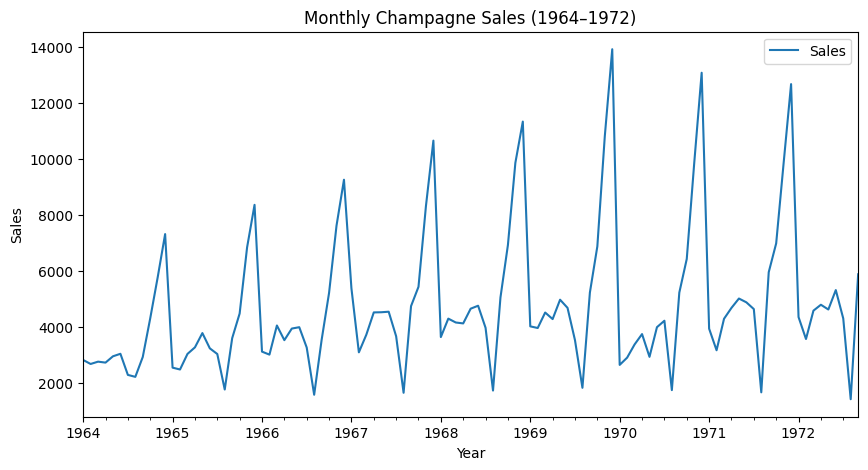

In [41]:
df.plot(figsize=(10,5))
plt.title("Monthly Champagne Sales (1964–1972)")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

Looking at the plot, champagne sales clearly follow a strong yearly pattern. Sales spike sharply around the same time each year likely during the holiday season then drop back down afterward, showing clear seasonality. Over time, the peaks also seem to get higher, suggesting a gradual increase in overall sales, meaning there may be a slight upward trend. The size of the ups and downs also grows in later years, indicating increasing variability. Overall, the series shows strong seasonal behavior with a mild upward trend, which suggests that a seasonal time-series model would likely be appropriate for further analysis.

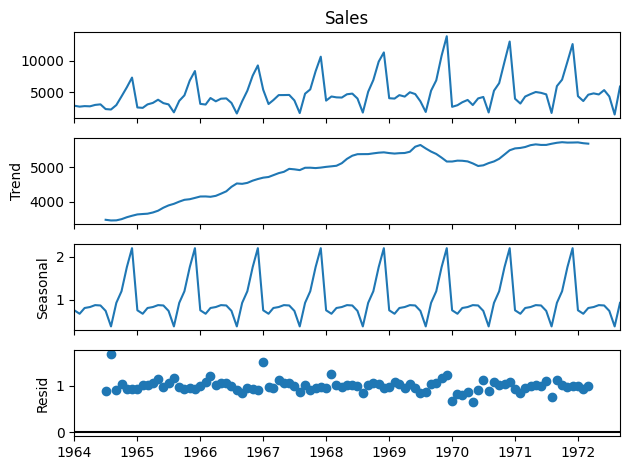

In [46]:
decomposition = seasonal_decompose(df['Sales'], model='multiplicative', period=12)
decomposition.plot()
plt.show()

The decomposition plot breaks the series into its main components and makes the patterns easier to see. The trend component shows that champagne sales gradually increased from the mid-1960s until around 1969, after which they level off slightly but remain relatively high. The seasonal component displays a very consistent yearly pattern with sharp peaks occurring at the same time each year, indicating strong seasonality in monthly sales. The residual component appears mostly random without a clear pattern, suggesting that most of the structure in the data is explained by the trend and seasonal effects. Overall, this confirms that the series is strongly seasonal with a moderate upward trend, which supports using a seasonal time series model for forecasting.


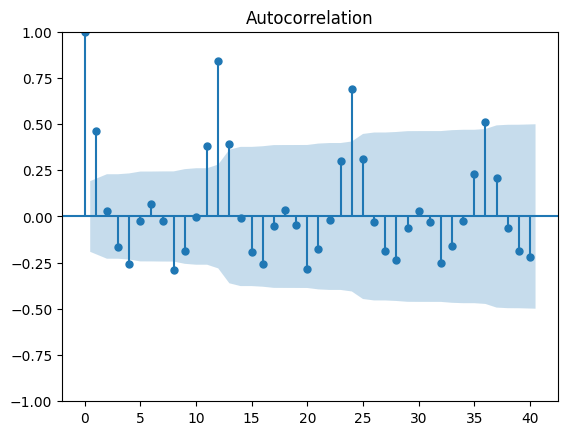

In [53]:
plot_acf(df['Sales'], lags=40)
plt.show()

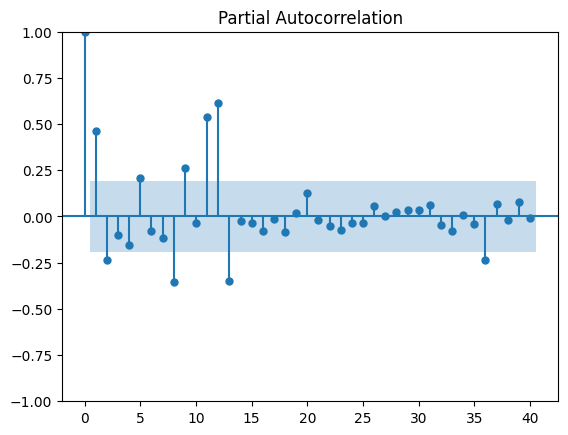

In [55]:
plot_pacf(df['Sales'], lags=40)
plt.show()

**ACF:** The ACF plot shows strong autocorrelation with clear spikes at lag 12 and its multiples, indicating a strong yearly seasonal pattern in the monthly champagne sales data.

**PACF:** The PACF plot shows significant spikes at early lags and around lag 12, suggesting the presence of autoregressive effects and supporting the use of a seasonal ARIMA-type model.


**Linking to Modelling Approach**

* The decomposition plot shows a clear upward trend and strong repeating yearly seasonality, suggesting the need for a seasonal time-series model.

* The ACF plot has strong spikes at lag 12 and its multiples, confirming annual seasonality and indicating that seasonal terms should be included in the model**.

* The PACF plot shows significant spikes at early lags and around lag 12, suggesting autoregressive components, supporting the use of a SARIMA model for forecasting


### III: Modelling

In [85]:
ets_model = ExponentialSmoothing(
    df['Sales'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()
print(ets_model.summary())


C:\Users\rgala\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                    Sales   No. Observations:                  105
Model:             ExponentialSmoothing   SSE                       36520099.033
Optimized:                         True   AIC                           1371.738
Trend:                         Additive   BIC                           1414.202
Seasonal:                Multiplicative   AICC                          1379.692
Seasonal Periods:                    12   Date:                 Fri, 13 Mar 2026
Box-Cox:                          False   Time:                         21:09:51
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.0757143                alpha                 True
smoothing_trend          

In [87]:
sarima_model = SARIMAX(
    df['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit()

print(sarima_model.summary())

C:\Users\rgala\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\rgala\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  105
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -738.402
Date:                            Fri, 13 Mar 2026   AIC                           1486.804
Time:                                    21:11:39   BIC                           1499.413
Sample:                                01-01-1964   HQIC                          1491.893
                                     - 09-01-1972                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2790      0.081      3.433      0.001       0.120       0.438
ma.L1         -0.9494      0.043   

### Insights from the above Models:
The AR(1) and MA(1) terms are statistically significant (p-values < 0.05), meaning the model successfully captures short-term autocorrelation in the series. However, the seasonal AR and MA terms at lag 12 are not statistically significant, suggesting the seasonal component may not be strongly contributing in this particular SARIMA specification.
The diagnostic tests look acceptable. The Ljung-Box test has a p-value of 0.61, indicating the residuals do not show significant autocorrelation — meaning the model has captured most of the time dependence in the data. The heteroskedasticity test is also not significant, suggesting relatively stable variance in the residuals.
Comparing the two models on the full dataset, the ETS model produces a lower AIC (1371.7) than SARIMA (1486.8), suggesting it provides a better overall fit for this data. This is likely because exponential smoothing models tend to perform well when seasonality is strong and consistent, as is the case here.

**Note:** The AIC figures above are from models fitted on the full dataset for exploratory comparison only. Both models are refit on training data in the forecasting section below, where performance is evaluated on unseen test data using MAE and RMSE.

## IV Forecasting

In [91]:
#Lets Use the last 12 months as test data.
train = df[:-12]
test = df[-12:]

In [95]:
#Refit
ets_model = ExponentialSmoothing(
    train['Sales'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()


C:\Users\rgala\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [97]:
sarima_model = SARIMAX(
    train['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit()


C:\Users\rgala\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\rgala\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [99]:
ets_forecast = ets_model.forecast(12)
sarima_forecast = sarima_model.forecast(12)


In [103]:
# ETS metrics
ets_mae = mean_absolute_error(test['Sales'], ets_forecast)
ets_rmse = np.sqrt(mean_squared_error(test['Sales'], ets_forecast))

# SARIMA metrics
sarima_mae = mean_absolute_error(test['Sales'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test['Sales'], sarima_forecast))

print("ETS MAE:", ets_mae)
print("ETS RMSE:", ets_rmse)

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)


ETS MAE: 371.8570254310935
ETS RMSE: 516.1671524693243
SARIMA MAE: 410.00128932810134
SARIMA RMSE: 501.5704782571233


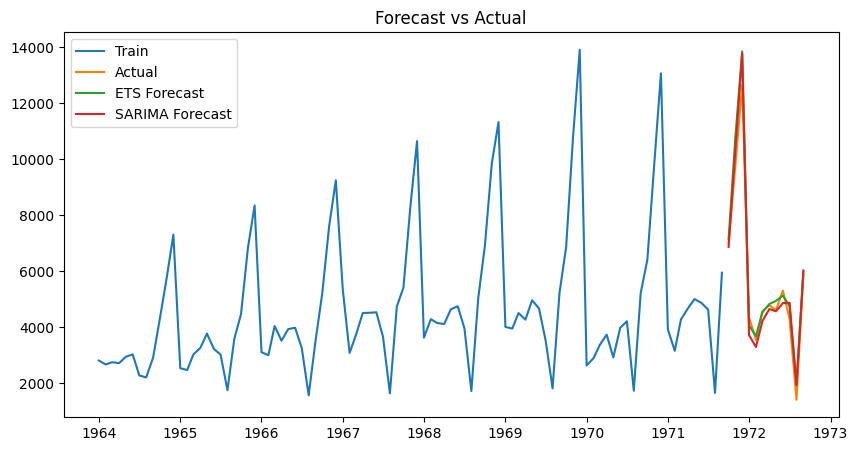

In [109]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, ets_forecast, label='ETS Forecast')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')

plt.legend()
plt.title("Forecast vs Actual")
plt.show()


### Lets have a closer look at only the Test Period Forecast

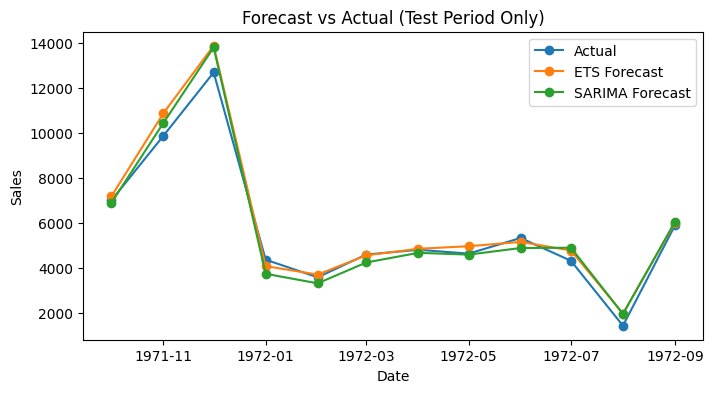

In [107]:
plt.figure(figsize=(8,4))

plt.plot(test.index, test['Sales'], label='Actual', marker='o')
plt.plot(test.index, ets_forecast, label='ETS Forecast', marker='o')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', marker='o')

plt.title("Forecast vs Actual (Test Period Only)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


## Conclusion and Limitation
The analysis shows that monthly champagne sales exhibit a clear seasonal pattern with a gradual upward trend over time. Both ETS and SARIMA models were tested and both performed reasonably well on the held-out test period, closely tracking the actual sales values across most months. SARIMA achieved a slightly lower RMSE (501.6 vs 516.2) while ETS produced a lower MAE (371.9 vs 410.0), meaning neither model strictly dominates the other. 

**Limitation**
However, the analysis assumes that historical seasonal patterns will continue in the future and does not account for external factors such as economic conditions, marketing campaigns, or changes in consumer demand. Additionally, the dataset is relatively small, which may limit the ability of the models to fully capture longer-term structural changes.